# 01_回归算法-支持向量回归

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/housing.csv`。

转写调整：

- 从本地 housing.csv 构造加州房价特征，删除缺失行，固定抽样 2500 行；load_local_housing(sample_size=None) 可运行全量有效数据。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文咱们一起来聊聊，支持向量回归 ！

支持向量回归（SVR，Support Vector Regression）是一种用来做 **回归分析** 的机器学习方法。

它是支持向量机（SVM）的一个变种，虽然 SVM 主要用于分类任务，但 SVR 主要用于预测 **连续数值**（比如房价、股票价格、温度等）。

当一名数据工程师，要根据房子的面积来预测房价。目标是找到一条“最合适”的直线（或者更复杂的曲线），让它尽可能贴合数据点，但又不过分追求每个点都完全匹配。

SVR 的核心思想：

1. **建立一个“宽度”可控的间隔带**（ε-tube），让一部分数据点可以在这个带子里，而不强求它们完全对齐预测值。
2. **重点关注异常点（支持向量）**，也就是那些落在间隔带外的数据点，这些点决定了模型的最终形状。
3. **优化损失函数**，让模型在误差不超过 ε 的情况下，保持最简单的形式（也就是尽可能光滑、不复杂）。

#### SVR 和普通回归的区别

| **对比项** | **普通回归（如线性回归）** | **SVR** |
|-|-|-|
| 目标 | 让预测值尽可能接近真实值 | 允许一定误差，只关注关键点 |
| 计算方式 | 最小化整体误差 | 重点关注支持向量 |
| 适用场景 | 适用于简单的线性关系 | 适用于复杂的非线性关系 |

再来一个例子，当你在训练一只 **“聪明的松鼠”** 来预测某天树上的苹果有多大。

- 线性回归会告诉它：“尽量给出一个最接近实际情况的预测，哪怕误差很小都要优化。”
- SVR 会告诉它：“只要预测误差在某个范围（ε）内，就不用太纠结，只关注那些明显不对劲的情况。”

这样，松鼠就能更高效地学习，不会被一些无关紧要的小误差干扰太多。

#### 什么时候用 SVR？

- **数据有非线性关系**（比如天气温度 vs. 电力需求）。
- **不希望过度拟合**，而是允许一点点误差（避免噪声影响）。
- **数据量不算特别大**，因为 SVR 在大规模数据下计算较慢。

## 原理详解

支持向量回归核心思想是：**在允许一定误差的情况下，寻找一个最优的超平面，使得大多数数据点都落在该超平面的 ε-间隔内，同时使模型的复杂度最小**。

### 1. 问题定义

给定训练数据集：


$$
D = \{ (x_1, y_1), (x_2, y_2), ..., (x_n, y_n) \}, \quad x_i \in \mathbb{R}^d, \quad y_i \in \mathbb{R}
$$


目标是学习一个回归函数 $f(x)$，使其能够对新样本 $x$进行预测：


$$
f(x) = w^T x + b
$$


其中：

$w$是权重向量，

$b$是偏置项。

### 2. 目标函数的构造

SVR 试图找到一个超平面，使得所有数据点的预测误差在一个可以接受的范围 **ε** 内，即：  
$|y_i - (w^T x_i + b)| \leq \epsilon, \quad \forall i$  
这意味着：

- 只要预测误差在 $\epsilon$范围内，我们就不会惩罚模型。
- 但如果预测值超出了这个范围，就需要引入 **松弛变量** 来表示超出的程度。

### 3. 松弛变量引入

由于数据可能会落在 ε 之外，我们引入松弛变量 $\xi_i, \xi_i^*$：

$\xi_i$表示 **实际值高于预测范围** 多少。

$\xi_i^*$表示 **实际值低于预测范围** 多少。

于是，我们的约束条件变为：  
$y_i - w^T x_i - b \leq \epsilon + \xi_i$  
$w^T x_i + b - y_i \leq \epsilon + \xi_i^*$  
$\xi_i, \xi_i^* \geq 0$  
这些松弛变量允许一定的误差，但代价是会增加优化目标的损失。

### 4. 优化目标

为了找到一个最优的回归函数，我们需要最小化：

1. **模型复杂度**：我们希望 $w$尽可能小，以避免过拟合。因此，我们的正则化项是：  
$\frac{1}{2} ||w||^2$
2. **误差损失**：超出 ε 范围的误差要被最小化，即：  
$C \sum_{i=1}^{n} (\xi_i + \xi_i^*)$  
其中 $C$是一个超参数，控制模型复杂度和误差的权衡。

最终，我们的优化问题变为：  
$\min_{w, b, \xi_i, \xi_i^*} \quad \frac{1}{2} ||w||^2 + C \sum_{i=1}^{n} (\xi_i + \xi_i^*)$  
$\text{subject to:} \quad\begin{cases}y_i - w^T x_i - b \leq \epsilon + \xi_i \\w^T x_i + b - y_i \leq \epsilon + \xi_i^* \\\xi_i, \xi_i^* \geq 0, \quad i = 1, 2, ..., n\end{cases}$

### 5. 对偶问题的推导

为了求解该优化问题，我们使用 **拉格朗日对偶法**。定义拉格朗日函数：


$$
L(w, b, \xi_i, \xi_i^*, \alpha_i, \alpha_i^*, \eta_i, \eta_i^*) =\frac{1}{2} ||w||^2 + C \sum_{i=1}^{n} (\xi_i + \xi_i^*)
$$


$$
- \sum_{i=1}^{n} \alpha_i (\epsilon + \xi_i - y_i + w^T x_i + b)
$$


$$
- \sum_{i=1}^{n} \alpha_i^* (\epsilon + \xi_i^* + y_i - w^T x_i - b)
$$


$$
- \sum_{i=1}^{n} \eta_i \xi_i - \sum_{i=1}^{n} \eta_i^* \xi_i^*
$$


其中：

- $\alpha_i, \alpha_i^* \geq 0$是拉格朗日乘子，对应于约束条件。
- $\eta_i, \eta_i^* \geq 0$是对应松弛变量的非负约束。

通过求偏导数并令其为零，我们得到：  
$w = \sum_{i=1}^{n} (\alpha_i - \alpha_i^*) x_i$  
$\sum_{i=1}^{n} (\alpha_i - \alpha_i^*) = 0$

将这些结果带回原问题，最终可以得到对偶问题：


$$
\max_{\alpha, \alpha^*} \sum_{i=1}^{n} y_i (\alpha_i - \alpha_i^*) - \epsilon \sum_{i=1}^{n} (\alpha_i + \alpha_i^*)
$$


$$
- \frac{1}{2} \sum_{i=1}^{n} \sum_{j=1}^{n} (\alpha_i - \alpha_i^*)(\alpha_j - \alpha_j^*) x_i^T x_j
$$


$$
\text{subject to} \quad 0 \leq \alpha_i, \alpha_i^* \leq C, \quad \sum_{i=1}^{n} (\alpha_i - \alpha_i^*) = 0
$$


### 6. 核方法引入

在非线性回归问题中，我们可以将数据映射到高维空间：  
$\phi: x \to \phi(x)$  
然后利用 **核函数** 计算点积：  
$K(x_i, x_j) = \phi(x_i)^T \phi(x_j)$  
这样，我们的回归函数变为：  
$f(x) = \sum_{i=1}^{n} (\alpha_i - \alpha_i^*) K(x_i, x) + b$

常见的核函数：

1. **线性核**：$K(x_i, x_j) = x_i^T x_j$
2. **多项式核**：$K(x_i, x_j) = (x_i^T x_j + c)^d$
3. **高斯核（RBF 核）**：$K(x_i, x_j) = \exp(-\gamma ||x_i - x_j||^2)$

### 7. SVR 的算法流程

1. 选择合适的 **核函数**（如线性核、多项式核、RBF 核）。
2. 设定超参数 **C 和 ε**（C 控制误差惩罚，ε 决定忽略的误差范围）。
3. 计算 **核矩阵**，构造二次优化问题。
4. 使用 **SMO（序列最小优化）** 或 **QP（二次规划）** 方法求解拉格朗日乘子 $\alpha, \alpha^*$。
5. 计算 **回归函数 $f(x)$**，用于预测新数据。

## 完整案例

我们使用 **支持向量回归（SVR）** 来预测 **房价**，并进行详细的 **数据分析、可视化、参数优化**。

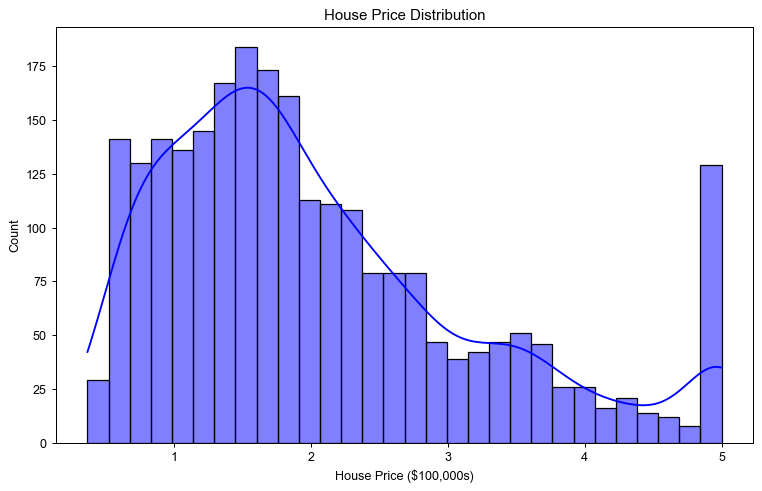

Best Parameters: {'C': 1, 'epsilon': 0.2, 'gamma': 'scale'}
MAE: 0.468, RMSE: 0.680, R^2: 0.632


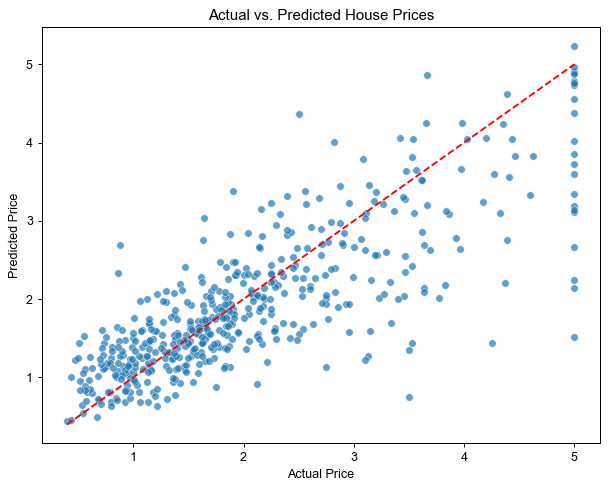

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from notebook_support import load_local_housing
# 1. 加载California房价数据
housing = load_local_housing()
data = pd.DataFrame(housing.data, columns=housing.feature_names)
data['PRICE'] = housing.target

# 2. 数据探索
plt.figure(figsize=(10, 6))
sns.histplot(data['PRICE'], bins=30, kde=True, color='blue')
plt.xlabel('House Price ($100,000s)')
plt.ylabel('Count')
plt.title('House Price Distribution')
plt.show()

# 3. 选择特征和目标变量
X = data[['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']]
y = data['PRICE']

# 4. 数据划分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 数据标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. SVR 模型训练（使用 RBF 核）
svr = SVR(kernel='rbf')
param_grid = {
    'C': [1, 10],
    'epsilon': [0.1, 0.2],
    'gamma': ['scale', 'auto']
}
grid_search = GridSearchCV(svr, param_grid, cv=5, scoring='r2', n_jobs=1, error_score='raise')
grid_search.fit(X_train_scaled, y_train)

# 7. 预测与评估
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Best Parameters: {grid_search.best_params_}')
print(f'MAE: {mae:.3f}, RMSE: {rmse:.3f}, R^2: {r2:.3f}')

# 8. 结果可视化
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted House Prices')
plt.show()

**数据加载**：使用 `load_local_housing()` 读取房价数据。

**数据探索**：绘制房价分布直方图，分析数据趋势。

![原文参考图，当前结果见代码输出](attachments/img_019.png)

**特征选择**：选择与房价关系密切的变量（收入、房间数、居住人数、房龄）。

**数据标准化**：使用 `StandardScaler()` 让特征具有相同尺度。

**模型优化**：采用 **GridSearchCV** 进行超参数调优（`C`，`epsilon`，`gamma`）。

**预测与评估**：

- **MAE（平均绝对误差）**：衡量预测值与真实值的绝对误差。
- **RMSE（均方根误差）**：衡量误差的标准偏差。
- **R²（决定系数）**：表示模型对数据的拟合程度。

**预测值 vs. 真实值** 散点图，分析误差分布。

![原文参考图，当前结果见代码输出](attachments/img_020.png)

这个案例展示了 **SVR 在回归问题中的应用**，并通过 **网格搜索优化超参数**，提升了模型性能。

## 模型分析

### 支持向量回归优缺点

**优点**：

1. **非线性拟合能力强**：SVR 通过 **核函数（如 RBF 核）** 能够很好地建模非线性关系，在房价预测等复杂问题上比线性回归更强大。
2. **对小误差不敏感**：SVR 采用 **ε-不敏感损失函数**，允许小范围误差不影响模型，从而提高鲁棒性。
3. **适用于高维数据**：即使有多个影响房价的因素，SVR 仍然能够处理，并保持较好的性能。
4. **可控误差范围**：可以通过 **ε 参数** 调整误差范围，提高模型的泛化能力。

**缺点**：

1. **计算复杂度高**：SVR 的训练复杂度较高，尤其是当数据量较大时，计算成本较高，不适合大规模数据集。
2. **参数调优较难**：超参数（如 `C`、`ε` 和 `gamma`）的选择对模型表现影响很大，需要使用 **网格搜索（GridSearchCV）** 或其他调参方法来优化。
3. **对极端异常值仍可能受影响**：尽管 **ε-不敏感损失函数** 能够忽略小误差，但对于远离数据分布的极端值，SVR 仍然可能受影响。

### SVR 与相似算法的对比

| **算法** | **适用场景** | **计算复杂度** | **对异常值的鲁棒性** | **适用于大数据** | **是否支持非线性关系** |
|-|-|-|-|-|-|
| **支持向量回归（SVR）** | 适用于 **小中型数据**，非线性关系明显的数据。 | **高**，训练慢。 | **较强**，但仍可能受极端异常值影响。 | **不适合** 百万级数据。 | **是**，通过 **核函数** 支持非线性。 |
| **线性回归（LR）** | 数据是 **线性关系** 时最优，解释性强。 | **低**，计算快。 | **对异常值敏感**，易受极端值影响。 | **非常适合** 大数据。 | **否**，仅适用于线性关系。 |
| **决策树回归（DTR）** | 适用于 **规则复杂、非线性数据**，易解释。 | **适中**，训练速度快。 | **对异常值不敏感**，可以自动忽略异常点。 | **适合中等规模数据**。 | **是**，能建模复杂的 **非线性关系**。 |
| **随机森林回归（RFR）** | 适用于 **非线性、多特征** 数据，减少过拟合。 | **高**，训练较慢但预测快。 | **对异常值较强鲁棒性**。 | **适合大规模数据**，可并行计算。 | **是**，能建模复杂的 **非线性关系**。 |
| **梯度提升回归（GBR）** | 适用于 **复杂模式数据**，在 Kaggle 竞赛中常用。 | **高**，训练慢但性能优秀。 | 依赖超参数调优，否则容易过拟合。 | **适合大规模数据**，但训练耗时。 | **是**，能捕捉复杂的 **非线性关系**。 |

### SVR 适用场景

1. **数据量适中（几千到几万条样本）**，过大会导致训练时间过长。
2. **数据具有非线性关系**，但又不希望使用树模型（如随机森林）。
3. **希望对误差范围有明确控制**，不希望过度拟合小误差。
4. **数据维度较高**，但特征数不至于过于庞大，否则计算开销会增加。

### 什么时候考虑其他算法？

1. **数据量非常大（如百万级样本）**：SVR 计算复杂度高，训练时间长，建议使用 **随机森林（RFR）或梯度提升（GBR）**。
2. **数据具有明显的线性关系**：如果特征和目标值之间呈线性相关，**线性回归（LR）** 是更好的选择，计算更快，且结果更易解释。
3. **数据包含大量离散特征**：决策树（DTR）和梯度提升（GBR）更适合处理 **类别型变量**，比 SVR 具有更强的适应性。

### 结论

在本案例中，**SVR 适用于数据集较小、特征与房价关系可能是非线性的情况**。但如果数据规模较大，或者需要更强的非线性建模能力，**随机森林回归（RFR）和梯度提升回归（GBR）可能是更好的选择**。